## 6.2.1 a)

ID: 377

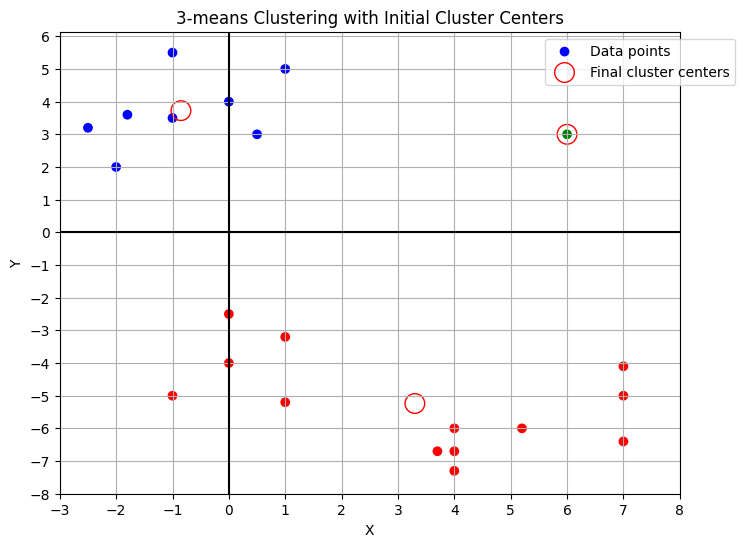

Final cluster centers:
 [[ 3.3        -5.23846154]
 [ 6.          3.        ]
 [-0.85        3.725     ]]
Cost: 142.44576923076923


In [51]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans
from matplotlib.colors import ListedColormap

data = np.loadtxt("big-dataset.txt", delimiter=",")

# set initial cluster centers
initial_centers = np.array([
    [0, 4],
    [1, 5],
    [-1, 5.5]
])

# 3-means with initial clusters
# no need to set n_init since init is array-like
kmeans = KMeans(n_clusters=3, init=initial_centers)
kmeans.fit(data)
cluster_centers = kmeans.cluster_centers_

final_centers = kmeans.cluster_centers_
kmeans_cost = kmeans.inertia_

colors = ['red', 'green', 'blue'] 
cmap = ListedColormap(colors)

plt.figure(figsize=(8, 6))
plt.scatter(data[:, 0], data[:, 1], c=kmeans.labels_, cmap=cmap, label='Data points')
plt.scatter(final_centers[:, 0], final_centers[:, 1], facecolors='none', edgecolors='red', marker='o', s=200, label='Final cluster centers')

plt.axhline(0, color='black', linewidth=1.5)
plt.axvline(0, color='black', linewidth=1.5)
plt.xlabel('X')
plt.ylabel('Y')
plt.title('3-means Clustering with Initial Cluster Centers')

plt.legend(loc="upper right", bbox_to_anchor=(1.1, 1))
plt.grid(True)
plt.xticks(range(int(data[:, 0].min()) - 1, int(data[:, 0].max()) + 2, 1))
plt.yticks(range(int(data[:, 1].min()) - 1, int(data[:, 1].max()) + 2, 1))
plt.show()

print("Final cluster centers:\n", final_centers)
print("Cost:", kmeans_cost)

## 6.2.2 b)

In [46]:
costs_b = []
labels_b = []
centers_b = []

# set init='random' to avoid using k-mean++
kmeans_b = KMeans(n_clusters=3, init='random', n_init=1)

for _ in range(40):
    kmeans_b.fit(data)
    costs_b.append(kmeans_b.inertia_)
    labels_b.append(kmeans_b.labels_)
    centers_b.append(kmeans_b.cluster_centers_)

Best 3-means cost: 93.6728611111111
Best cluster centers:
[[ 0.2        -3.98      ]
 [ 5.2375     -6.025     ]
 [-0.08888889  3.64444444]]
Best clustering count: 14


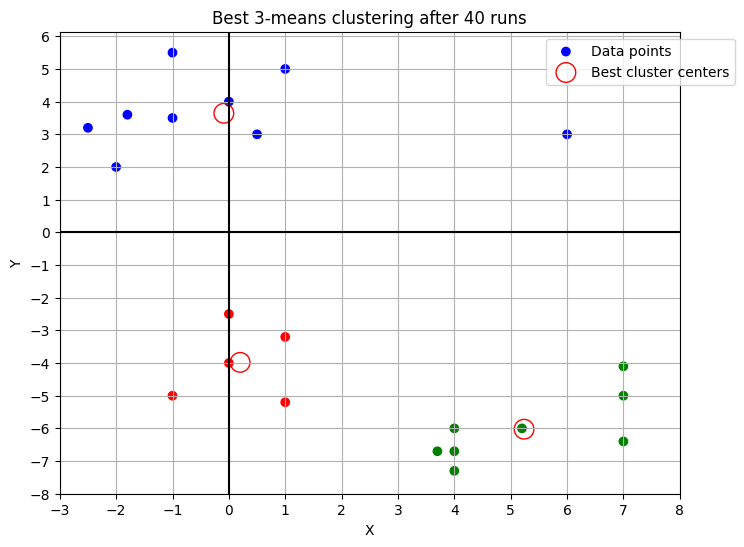

In [53]:
min_cost_b_index = np.argmin(costs_b)
best_cost_b = costs_b[min_cost_b_index]
best_labels_b = labels_b[min_cost_b_index]
best_centers_b = centers_b[min_cost_b_index]

# count the number of times the best clustering was 
# found within a given tolerance
tolerance = 1e-8
best_count_b = 0

for cost in costs_b:
    if abs(cost - best_cost_b) <= tolerance:
        best_count_b += 1

# Print the results
print(f"Best 3-means cost: {best_cost_b}")
print(f"Best cluster centers:\n{best_centers_b}")
print(f"Best clustering count: {best_count_b}")

plt.figure(figsize=(8, 6))
plt.scatter(data[:, 0], data[:, 1], c=best_labels_b, cmap=cmap, label='Data points')
plt.scatter(best_centers_b[:, 0], best_centers_b[:, 1], facecolors='none', edgecolors='red', marker='o', s=200, label='Best cluster centers')

plt.axhline(0, color='black', linewidth=1.5)
plt.axvline(0, color='black', linewidth=1.5)
plt.xlabel('X')
plt.ylabel('Y')
plt.title('Best 3-means clustering after 40 runs')

plt.legend(loc="upper right", bbox_to_anchor=(1.1, 1))
plt.grid(True)
plt.xticks(range(int(data[:, 0].min()) - 1, int(data[:, 0].max()) + 2, 1))
plt.yticks(range(int(data[:, 1].min()) - 1, int(data[:, 1].max()) + 2, 1))
plt.show()

## 6.2.3 C)

In [48]:
costs_c = []
labels_c = []
centers_c = []

kmeans_c = KMeans(n_clusters=3)

for _ in range(40):
    kmeans_c.fit(data)
    costs_c.append(kmeans_c.inertia_)
    labels_c.append(kmeans_c.labels_)
    centers_c.append(kmeans_c.cluster_centers_)

Best 3-means cost: 93.6728611111111
Best cluster centers:
[[-0.08888889  3.64444444]
 [ 5.2375     -6.025     ]
 [ 0.2        -3.98      ]]
Best clustering count: 35


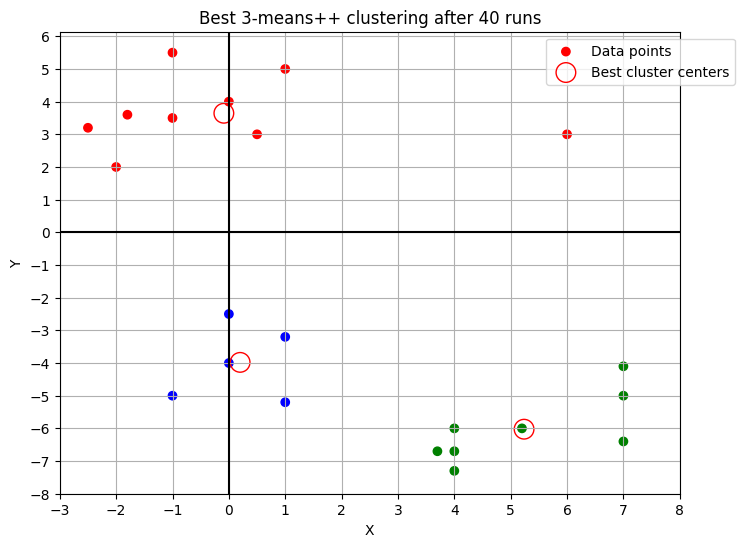

In [54]:
min_cost_c_index = np.argmin(costs_c)
best_cost_c = costs_c[min_cost_c_index]
best_labels_c = labels_c[min_cost_c_index]
best_centers_c = centers_c[min_cost_c_index]

# Count the number of times the best clustering was found within a given tolerance
tolerance = 1e-8
best_count_c = 0

for cost in costs_c:
    if abs(cost - best_cost_c) <= tolerance:
        best_count_c += 1

# Print the results
print(f"Best 3-means cost: {best_cost_c}")
print(f"Best cluster centers:\n{best_centers_c}")
print(f"Best clustering count: {best_count_c}")

plt.figure(figsize=(8, 6))
plt.scatter(data[:, 0], data[:, 1], c=best_labels_c, cmap=cmap, label='Data points')
plt.scatter(best_centers_c[:, 0], best_centers_c[:, 1], facecolors='none', edgecolors='red', marker='o', s=200, label='Best cluster centers')

plt.axhline(0, color='black', linewidth=1.5)
plt.axvline(0, color='black', linewidth=1.5)
plt.xlabel('X')
plt.ylabel('Y')
plt.title('Best 3-means++ clustering after 40 runs')

plt.legend(loc="upper right", bbox_to_anchor=(1.1, 1))
plt.grid(True)
plt.xticks(range(int(data[:, 0].min()) - 1, int(data[:, 0].max()) + 2, 1))
plt.yticks(range(int(data[:, 1].min()) - 1, int(data[:, 1].max()) + 2, 1))
plt.show()
